## Import libraries

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import (
    cross_validate, cross_val_predict,
)
from sklearn.metrics import classification_report, confusion_matrix, make_scorer
from xgboost import XGBClassifier

## Load data

In [72]:
BINARY_TARGET = True
INCLUDE_GEX = True
TEST_SIZE = 0.3

In [73]:
# Load gex_mat_corrected
gex_mat = pd.read_csv(f"../dataset/created/gex_mat_corrected.csv").set_index('sample_id').T
gex_mat['sample_id'] = gex_mat.index

print(gex_mat.shape)
gex_mat.head()

(136, 17380)


sample_id,R558Q,A1CF,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,AADACL2,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,sample_id
03660555B,3.978466,4.124259,3.734769,4.019265,4.662117,4.228288,6.278393,5.330995,4.199087,3.949955,...,5.637079,4.338339,4.622719,5.249535,4.132589,6.354585,8.035001,5.920833,6.096052,03660555B
03660598B,3.978466,4.123792,3.753701,4.028896,4.584599,4.241257,6.231589,5.383304,4.202587,3.963884,...,5.722772,4.350749,4.607248,5.209625,4.128846,6.463065,7.447238,5.927484,5.966280,03660598B
03660602B,3.978466,4.124239,3.747099,4.028700,4.607786,4.269241,5.721658,5.108462,4.192361,3.948235,...,5.595316,4.351685,4.609628,5.183949,4.147669,6.394659,8.022024,6.021049,6.327308,03660602B
04240076F,3.978466,4.123924,3.781177,4.022718,4.815906,4.246022,5.511833,5.159527,4.200447,3.974216,...,5.573082,4.360317,4.609541,5.163976,4.127292,6.345676,8.138114,6.007880,5.855316,04240076F
04240106F,3.978466,4.123219,3.736683,4.107132,4.613712,4.230606,6.366526,5.092868,4.194341,3.964832,...,5.468773,4.361592,4.639009,5.280776,4.125694,6.615345,7.408114,6.103008,6.347824,04240106F


In [74]:
# Load clinical_gex
clinical_gex = pd.read_csv(f"../dataset/created/clinical_gex.csv", low_memory=False)

print(clinical_gex.shape)
clinical_gex.head()

(136, 51487)


,patientID,sex,age,AJCC_stage,M_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,source,pfs_label,...,sept-05,sept-06,sept-07,sept-08,sept-09,sept-10,sept-11,sept-12,sept-14,sept-15
0,YR_3053,male,26,IV,M1B,elevated,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,YR_3708,female,58,IV,M1A,normal,no,no,Yan et al.,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,YR_3705,male,45,IV,M1A,normal,no,no,Yan et al.,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,YR_1106,male,48,IIIC,NaN,normal,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,YR_1110,male,33,IV,M1C,normal,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
# Metadata (not used as features)
_meta_cols = ['patientID', 'sample_id', 'pfs_label', 'source']

# Clinical feature groups
clinical_ordinal_col    = ['M_stage']
clinical_categorical_cols = ['sex', 'AJCC_stage', 'LDH', 'immunotherapy_treatment', 'pre_MAPKi_treatment']
clinical_numeric_col    = ['age']
drug_braf_cols          = ['cobimetinib', 'trametinib', 'dabrafenib', 'vemurafenib',
                           'C195W', 'K601I', 'MND', 'V600E', 'V600K', 'V600R'] 
drug_braf_cols          = [c for c in drug_braf_cols if c in clinical_gex.columns]

all_non_gex  = clinical_ordinal_col + clinical_categorical_cols + clinical_numeric_col + drug_braf_cols
CLINICAL_COLS = _meta_cols + all_non_gex
GEX_COLS = [c for c in clinical_gex.columns if c not in CLINICAL_COLS]

print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS)} = {len(CLINICAL_COLS)+len(GEX_COLS)}')

clinical + gex = 21 + 51466 = 51487


In [76]:
# Merge into clinical_gex_corrected
clinical_gex = clinical_gex[CLINICAL_COLS]

gex_mat_reset = gex_mat.reset_index()
clinical_gex = clinical_gex.merge(gex_mat_reset, on='sample_id', how='inner')
# clinical_gex.to_csv(f"../dataset/created/clinical_gex_corrected.csv", index=False)

print(clinical_gex.shape)

GEX_COLS = [c for c in clinical_gex.columns if c not in CLINICAL_COLS]
print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS)} = {len(CLINICAL_COLS)+len(GEX_COLS)}')

(136, 17401)
clinical + gex = 21 + 17380 = 17401


In [77]:
from sklearn.model_selection import train_test_split

# Split x, y
clinical_gex.columns = clinical_gex.columns.str.strip()
groups = clinical_gex['source']
y = clinical_gex['pfs_label']
x = clinical_gex.drop(['patientID', 'pfs_label', 'sample_id', 'source', 'index'], axis=1)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=TEST_SIZE, random_state=42
)

print(f'Train: clinical_gex shape {x_train.shape}')
print(f'Test: clinical_gex shape {x_test.shape}')
x_train.head()

Train: clinical_gex shape (95, 17396)
Test: clinical_gex shape (41, 17396)


,M_stage,sex,AJCC_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,age,cobimetinib,trametinib,dabrafenib,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
24,M1B,male,IV,normal,no,no,65,1,0,0,...,5.960274,5.815929,4.348689,4.641035,5.173216,4.126429,6.369914,7.562653,5.910625,6.140452
8,M1C,female,IV,normal,no,no,80,0,0,0,...,6.065379,5.769920,4.344479,4.609042,5.160862,4.128560,6.436675,7.548396,6.232713,6.015385
63,M1C,male,IV,elevated,no,no,55,0,0,0,...,6.275586,5.672903,4.346900,4.615370,5.245495,4.125694,6.445465,8.301250,5.984676,5.949911
22,M1C,male,IV,elevated,no,no,36,0,0,0,...,6.137885,5.550390,4.387201,4.657902,5.118506,4.135895,6.542656,7.462244,6.003729,6.034609
18,M1C,female,IV,normal,no,no,64,0,0,0,...,5.870764,5.643968,4.377377,4.625220,5.343308,4.143073,6.482833,7.295728,6.296598,6.212619


In [78]:
print(f"\nTarget distribution:\n{y_train.value_counts().sort_index()}")


Target distribution:
pfs_label
0    49
1    46
Name: count, dtype: int64


## Preprocessing pipeline

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

if INCLUDE_GEX == True:
    remainder='passthrough'
else:
    remainder='drop'

clinical_preprocessor = ColumnTransformer(
    transformers=[
        ('m_stage', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(
                categories=[['M1A', 'M1B', 'M1C']],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan
            )),
        ]), clinical_ordinal_col),

        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
        ]), clinical_categorical_cols),

        ('age', SimpleImputer(strategy='median'), clinical_numeric_col),
        ('drug_braf', 'passthrough', drug_braf_cols)
    ],
    remainder=remainder # gene expressions
)

selection_pipe = Pipeline([
    ('clinical_prep', clinical_preprocessor),
    ('threshold',     VarianceThreshold(threshold=0.1)),
    ('kbest',         SelectKBest(f_classif, k=500)),
    ('rfe',           RFE(
        estimator=RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        step=0.1,                          
        n_features_to_select=15,
    )),
])


## Train model

In [80]:
CLASSIFIER = 'lr'
OPTUNA_TRIALS = 50

In [81]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import f1_score

logo = LeaveOneGroupOut()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

if CLASSIFIER == 'xgboost':
    if BINARY_TARGET:
        clf = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
        )
    else:
        clf = XGBClassifier(
            objective='multi:softprob',
            num_class=3,
            eval_metric='mlogloss',
            random_state=42,
        )
elif CLASSIFIER == 'lr':
    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            solver='saga',
            class_weight='balanced',
            max_iter=5000,
            random_state=42,
        ))
    ])
    
full_pipe=Pipeline([
    ('selection', selection_pipe),
    ('model', clf)
])
    

def objective(trial):
    if CLASSIFIER == 'xgboost':
        params = {
            'model__n_estimators':     200,
            'model__max_depth':        trial.suggest_int('model__max_depth', 2, 5),
            'model__learning_rate':    trial.suggest_float('model__learning_rate', 0.01, 0.3, log=True),
            'model__subsample':        trial.suggest_float('model__subsample', 0.5, 1.0),
            'model__colsample_bytree': trial.suggest_float('model__colsample_bytree', 0.3, 1.0),
            'model__reg_alpha':        trial.suggest_float('model__reg_alpha', 1e-4, 10.0, log=True),
            'model__reg_lambda':       trial.suggest_float('model__reg_lambda', 1e-4, 10.0, log=True),
            'model__min_child_weight': trial.suggest_int('model__min_child_weight', 1, 5),
            'model__gamma':            trial.suggest_float('model__gamma', 0.0, 2.0),
        }
    elif CLASSIFIER == 'lr':
        params = {
            'model__clf__C':        trial.suggest_float('model__clf__C', 1e-3, 10.0, log=True),
            'model__clf__l1_ratio': trial.suggest_float('model__clf__l1_ratio', 0.0, 1.0),
        }

    full_pipe.set_params(**params)
    scores = cross_val_score(full_pipe, x_train, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=OPTUNA_TRIALS)

print("Best params:", study.best_params)
print("Best CV F1 macro:", study.best_value)

[I 2026-04-28 13:48:28,188] A new study created in memory with name: no-name-8504c909-ed92-4de5-8bc7-ad2a9cbd0dd3
[I 2026-04-28 13:48:31,900] Trial 0 finished with value: 0.47391095880832046 and parameters: {'model__clf__C': 0.04381496211077918, 'model__clf__l1_ratio': 0.17581486638313126}. Best is trial 0 with value: 0.47391095880832046.
[I 2026-04-28 13:48:34,517] Trial 1 finished with value: 0.5386220904699166 and parameters: {'model__clf__C': 0.24211819572415336, 'model__clf__l1_ratio': 0.44681651552668067}. Best is trial 1 with value: 0.5386220904699166.
[I 2026-04-28 13:48:37,117] Trial 2 finished with value: 0.5322171292759528 and parameters: {'model__clf__C': 0.40295797353867857, 'model__clf__l1_ratio': 0.681190851891352}. Best is trial 1 with value: 0.5386220904699166.
[I 2026-04-28 13:48:38,638] Trial 3 finished with value: 0.5220416906794615 and parameters: {'model__clf__C': 0.8279133346175382, 'model__clf__l1_ratio': 0.5972529984914907}. Best is trial 1 with value: 0.538622

Best params: {'model__clf__C': 0.09450013114836578, 'model__clf__l1_ratio': 0.9983646961824146}
Best CV F1 macro: 0.5673730617208878


In [82]:
# Train model
full_pipe.set_params(**study.best_params)
full_pipe.fit(x_train, y_train)     

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('selection', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clinical_prep', ...), ('threshold', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'p

## Validation on test

              precision    recall  f1-score   support

  Short resp       0.57      0.57      0.57        21
   Long resp       0.55      0.55      0.55        20

    accuracy                           0.56        41
   macro avg       0.56      0.56      0.56        41
weighted avg       0.56      0.56      0.56        41



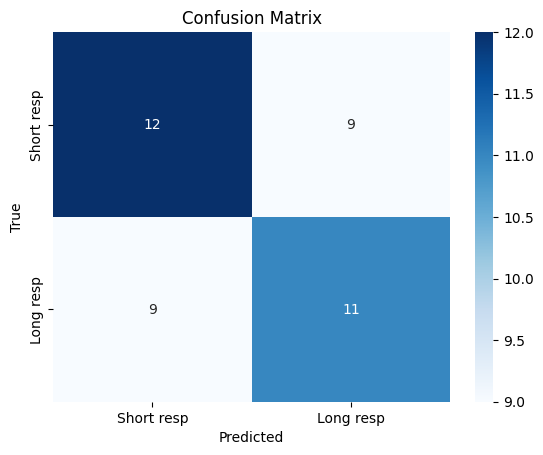

In [83]:
y_pred = full_pipe.predict(x_test)    # Validate

if BINARY_TARGET == True:
    target_names = ['Short resp', 'Long resp']
else:
    target_names = ['Short resp', 'Intermediate', 'Long resp']

print(classification_report(
    y_test, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## Explanability

### SHAP values

In [84]:
print(x_test.shape)
x_test.head()

(41, 17396)


,M_stage,sex,AJCC_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,age,cobimetinib,trametinib,dabrafenib,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
107,M1A,male,IV,normal,no,no,66,0,1,1,...,6.868154,5.037027,3.955536,4.501743,6.058288,3.645818,6.636937,7.672875,6.183903,6.198183
97,M1B,male,IV,normal,no,no,41,0,1,1,...,6.529449,6.735127,4.236383,5.288854,4.916377,4.363828,6.458318,6.935491,5.913632,6.271741
98,M1B,male,IV,normal,no,no,41,0,1,1,...,6.356250,6.577828,4.121068,5.080676,4.857143,4.456335,6.455203,6.832736,5.902853,6.190387
32,M1B,male,IV,normal,no,no,58,0,0,0,...,5.853828,5.566030,4.369998,4.628020,5.170922,4.129640,6.464191,7.738288,5.912982,6.389861
117,NaN,female,IV,NaN,no,no,25,0,0,0,...,5.827745,5.405886,4.339482,4.591697,5.333726,4.138512,6.303220,6.573445,6.013801,5.909108


In [93]:
import shap
shap.initjs()

x_train_sel    = full_pipe.named_steps['selection'].transform(x_train)
x_test_sel     = full_pipe.named_steps['selection'].transform(x_test)

scaler   = full_pipe.named_steps['model'].named_steps['scaler']
lr_model = full_pipe.named_steps['model'].named_steps['clf']

x_train_scaled = scaler.transform(x_train_sel)
x_test_scaled  = scaler.transform(x_test_sel)

prep = full_pipe.named_steps['selection'].named_steps['clinical_prep']
names = prep.get_feature_names_out()  # e.g. "categorical__sex_F", "drug_braf__V600E", etc.

for step in ['threshold', 'kbest', 'rfe']:
    sel = full_pipe.named_steps['selection'].named_steps[step]
    names = names[sel.get_support()]

all_feature_names = [n.split('__', 1)[-1] for n in names]

explainer = shap.LinearExplainer(lr_model, x_train_scaled)
shap_values = explainer(x_test_scaled)
shap_values.feature_names = all_feature_names

print(all_feature_names)

['BIRC2', 'CDH2', 'ERICH1', 'HES6', 'HK2', 'LOX', 'MAGEA1', 'PPHLN1', 'RPP25', 'SLC31A1', 'TBC1D16', 'TUBA8', 'UBE2V2', 'ZNF570', 'ZNF691']


### Waterfall plot

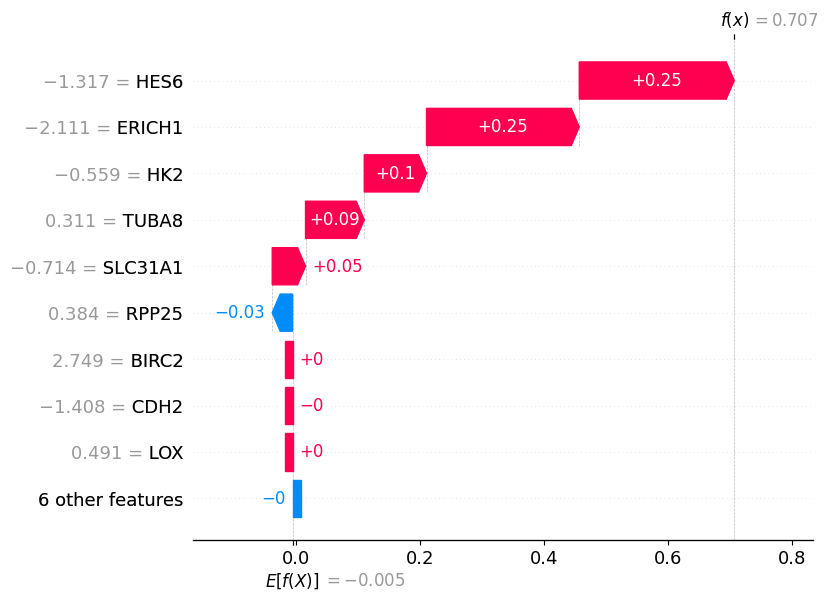

In [ ]:
sample_idx = 0    
class_idx = 0

shap.plots.waterfall(shap_values[sample_idx, :, class_idx])


### Force plot

In [97]:
shap.plots.force(shap_values[sample_idx, :, class_idx])

### Stacked force plot

In [98]:
shap.plots.force(shap_values[:, :, class_idx])


### Absolute mean SHAP

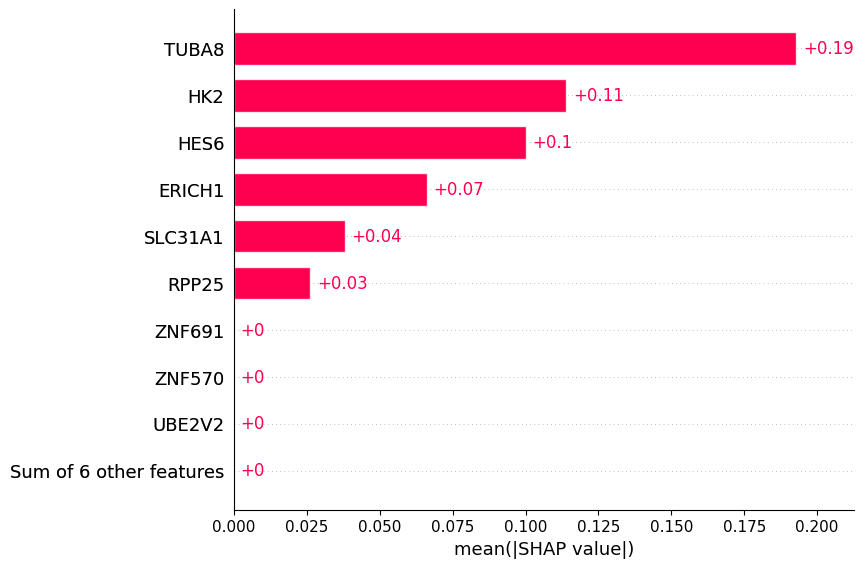

In [99]:
shap.plots.bar(shap_values[:, :, class_idx])

### Beeswarm plot

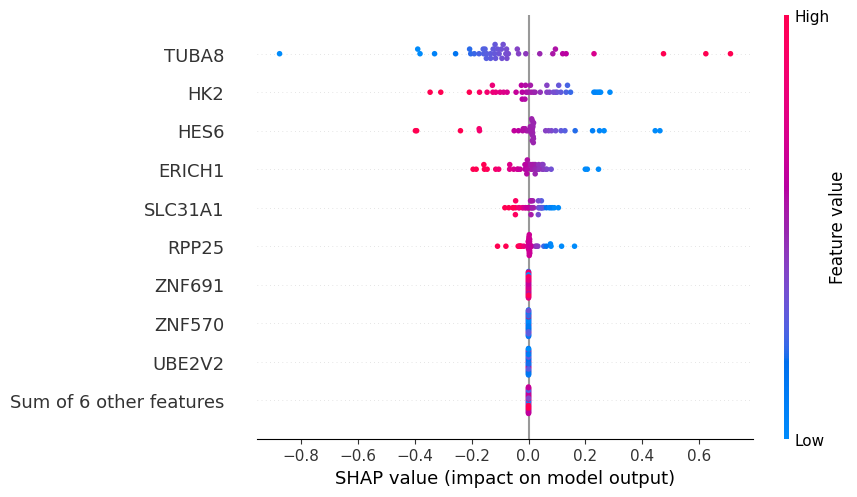

In [100]:
shap.plots.beeswarm(shap_values[:, :, class_idx])

### Dependence plots

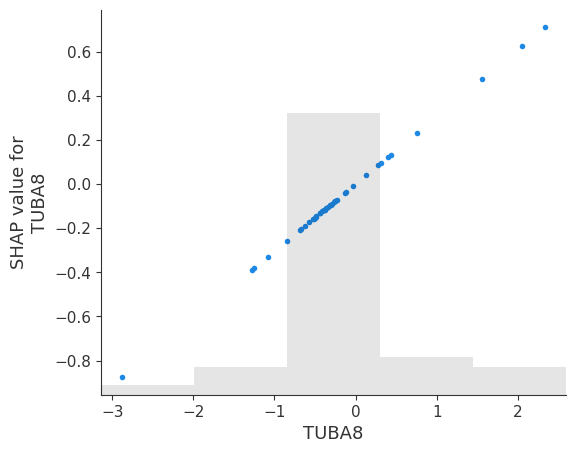

In [101]:
shap.plots.scatter(shap_values[:, 'TUBA8'])

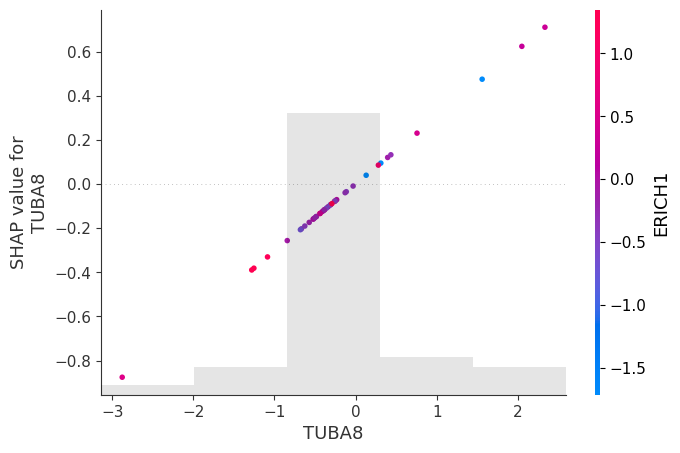

In [105]:
shap.plots.scatter(
    shap_values=shap_values[:, 'TUBA8'],
    color=shap_values[:, 'ERICH1']
)

### Heatmap plot

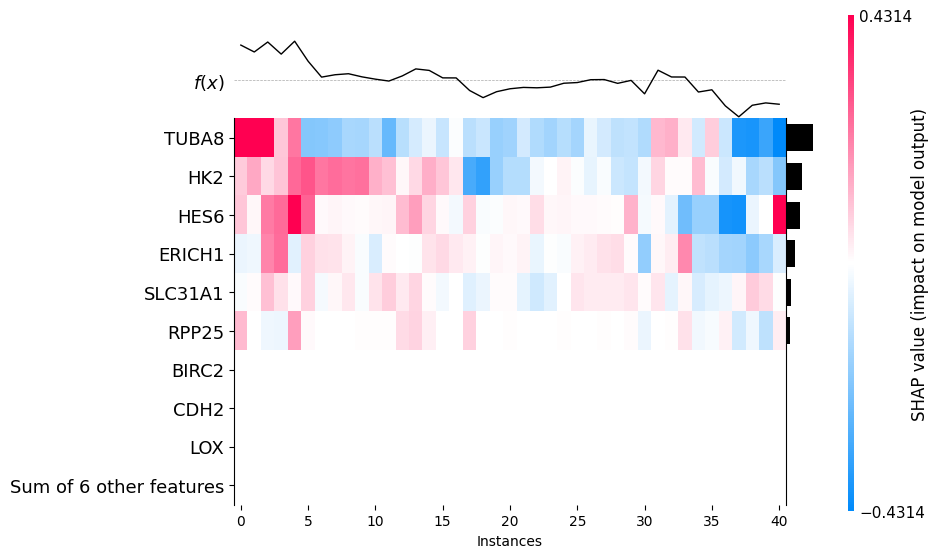

<Axes: xlabel='Instances'>

In [106]:
shap.plots.heatmap(shap_values[:, :, class_idx])